# Лабораторная 7

# ____________________________________________________________

Подключение библиотек и функций

In [3]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal
import statsmodels.api as sm

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = [11, 7]
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

def plot_time_freq(t, y):
    freq = np.fft.fftfreq(t.size, d=t[1]-t[0])
    Y = abs(np.fft.fft(y))
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    axes[0].plot(t, y, color="teal", linewidth=1.0)
    axes[0].set_title("Временная область", fontsize=12)
    axes[0].set_xlabel("Время", fontsize=11)
    axes[0].set_ylabel("Сигнал", fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[1].stem(np.fft.fftshift(freq), np.fft.fftshift(Y), linefmt="darkorange", markerfmt="o", basefmt="gray")
    axes[1].set_title("Частотная область", fontsize=12)
    axes[1].set_xlabel("Частота", fontsize=11)
    axes[1].set_xlim(-20, 20)
    axes[1].set_ylabel("|БПФ|", fontsize=11)
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def filter_plot(time, y_noisy, y_clean, y_filtered, legend_names, alpha=1):
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(time, y_noisy, "k", lw=1, alpha=0.5)
    ax.plot(time, y_clean, "teal", lw=3)
    ax.plot(time, np.real(y_filtered), "crimson", linestyle="--", lw=3, alpha=alpha)
    ax.legend(legend_names, fontsize=9)
    ax.set_xlabel("Время", fontsize=11)
    ax.set_ylabel("Амплитуда", fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def fourierPrediction(y, n_predict, n_harm=5):
    n = y.size
    t = np.arange(0, n)
    p = np.polyfit(t, y, 1)
    y_notrend = y - p[0] * t - p[1]
    y_freqdom = np.fft.fft(y_notrend)
    f = np.fft.fftfreq(n)
    indexes = np.argsort(np.absolute(y_freqdom))[::-1]
    t_ext = np.arange(0, n + n_predict)
    restored_sig = np.zeros(t_ext.size)
    for i in indexes[:1 + n_harm * 2]:
        amp = np.absolute(y_freqdom[i]) / n
        phase = np.angle(y_freqdom[i])
        restored_sig += amp * np.cos(2 * np.pi * f[i] * t_ext + phase)
    return restored_sig + p[0] * t_ext + p[1]

#### Задание 1

Синусоидальная компонента:


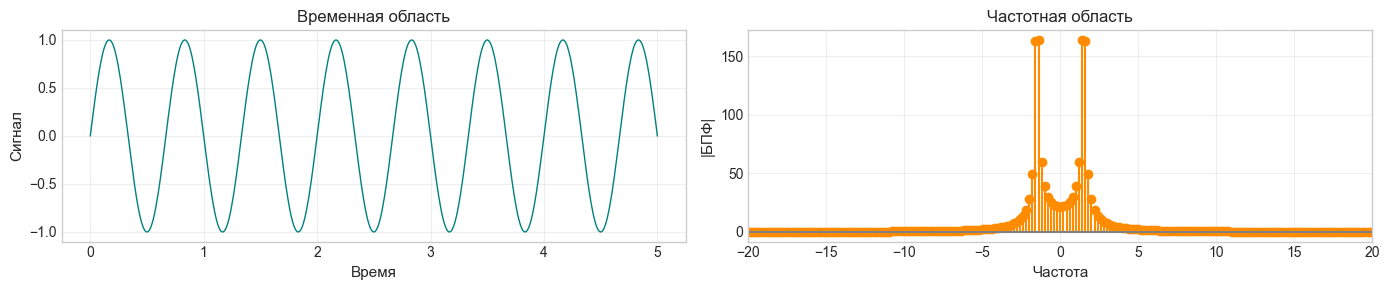

Трендовая компонента (парабола):


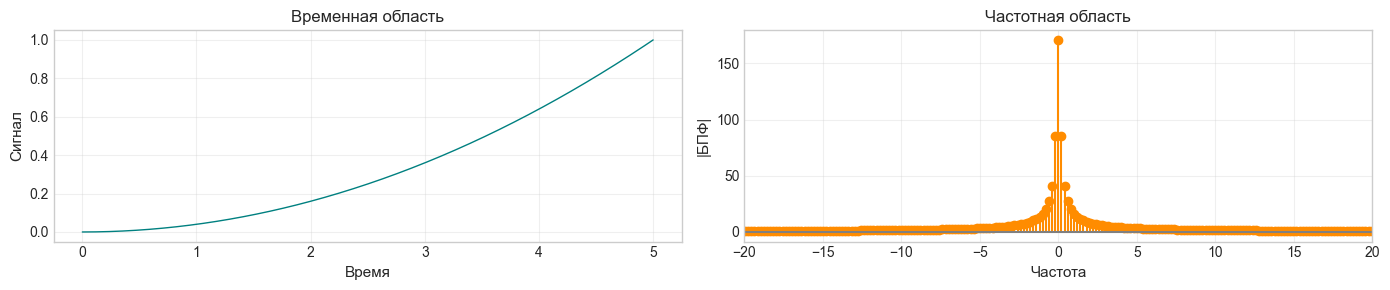

Шумовая компонента:


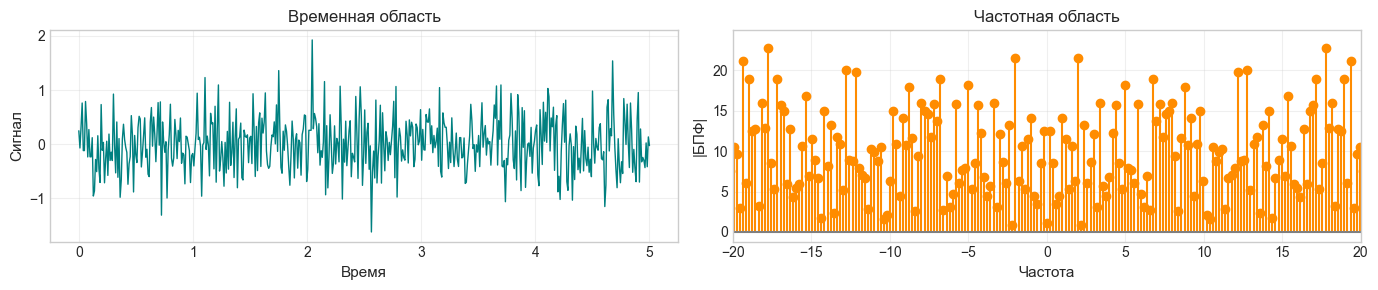

Суммарный сигнал:


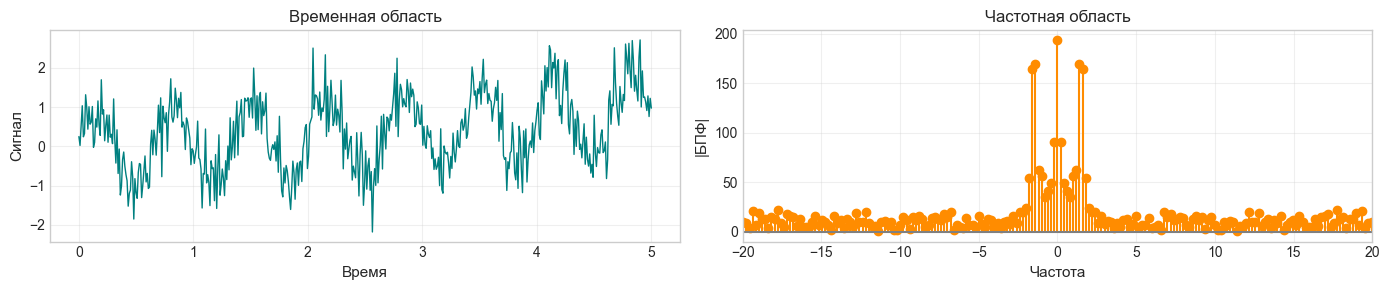

In [4]:
time = np.linspace(0, 5, 512)
freq = 1.5

y_sin  = np.sin(2 * np.pi * freq * time)
y_trend = (0.2 * time) ** 2
y_noise = 0.5 * np.random.randn(len(time))

print("Синусоидальная компонента:")
plot_time_freq(time, y_sin)

print("Трендовая компонента (парабола):")
plot_time_freq(time, y_trend)

print("Шумовая компонента:")
plot_time_freq(time, y_noise)

print("Суммарный сигнал:")
y_combined = y_sin + y_trend + y_noise
plot_time_freq(time, y_combined)

Синус: чистая синусоида, два симметричных пика в частотной области.

Тренд: параболический рост, вся энергия у нуля (низкие частоты).

Шум: хаотичные колебания, энергия распределена равномерно по всем частотам.

Суммарный сигнал: все три компонента видны и во временной, и в частотной области.

##### Доминирование каждого компонента

Влияние амплитуды компонента на FT суммарного сигнала

Доминирует синус:


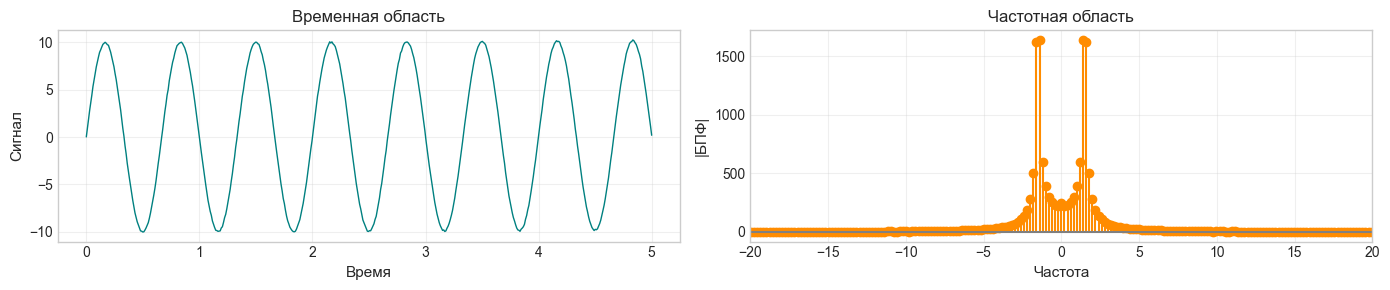

Доминирует тренд:


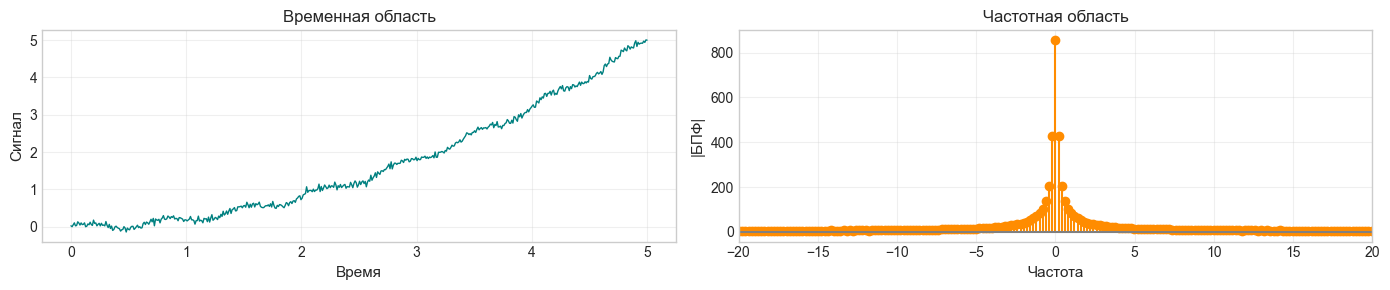

Доминирует шум:


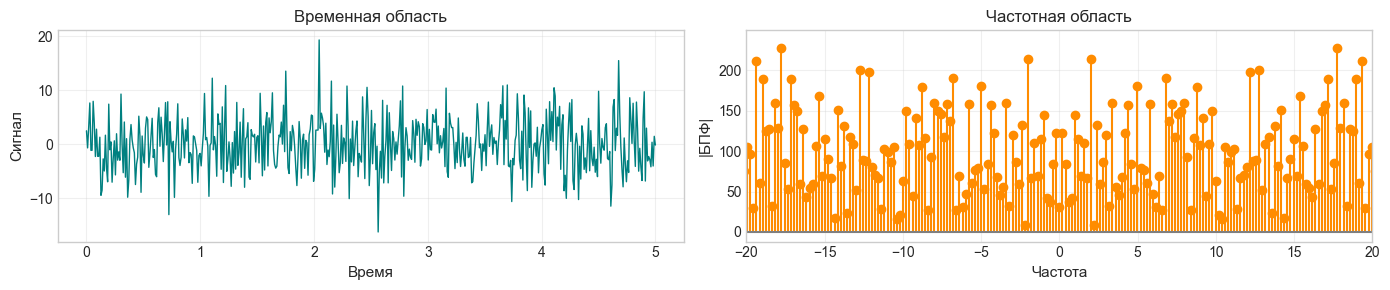

In [5]:
y_dom_sin = 10 * np.sin(2 * np.pi * freq * time) + 0.2 * y_trend + 0.1 * y_noise
print("Доминирует синус:")
plot_time_freq(time, y_dom_sin)

y_dom_trend = 0.1 * np.sin(2 * np.pi * freq * time) + 5 * y_trend + 0.1 * y_noise
print("Доминирует тренд:")
plot_time_freq(time, y_dom_trend)

y_dom_noise = 0.1 * np.sin(2 * np.pi * freq * time) + 0.1 * y_trend + 10 * y_noise
print("Доминирует шум:")
plot_time_freq(time, y_dom_noise)

Синус доминирует: чистая синусоида, пик у нуля и фон от шума практически исчезли.

Тренд доминирует: монотонный параболический рост. Огромный пик у нуля.

Шум доминирует: хаотичные колебания. Равномерный широкополосный фон по всем частотам.

##### Два синуса + константа

Два синуса + константа:


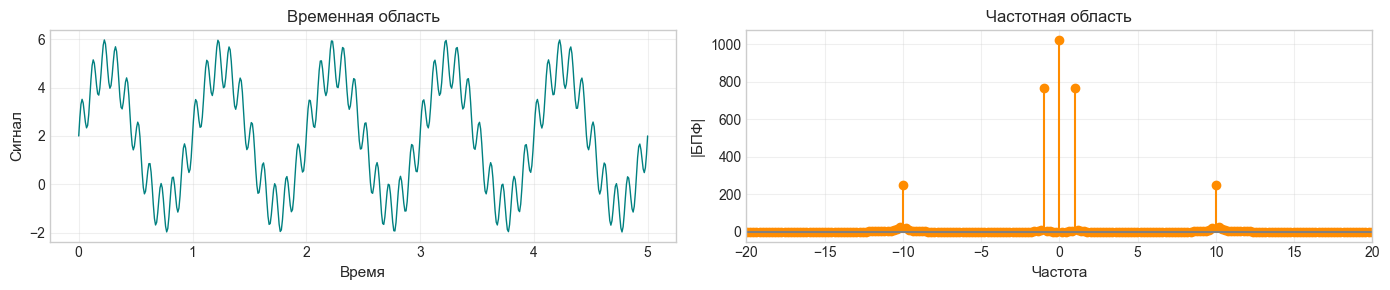

In [6]:
y_two = 3 * np.sin(2 * np.pi * 1 * time) + 1 * np.sin(2 * np.pi * 10 * time) + 2
print("Два синуса + константа:")
plot_time_freq(time, y_two)

Два синуса создают биение огибающую во временной области. Сигнал смещён вверх на 2. В частотной области три чётких пика: у нуля (константа) и на 1 и 10 Гц.

### Задание 2

Фильтр Тьюки

Фильтр Тьюки: alpha=0.1, div=8, MSE=36759.262


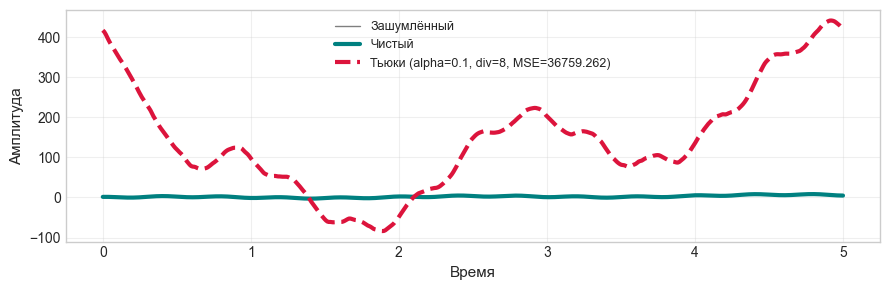

Фильтр Тьюки: alpha=0.1, div=16, MSE=9370.506


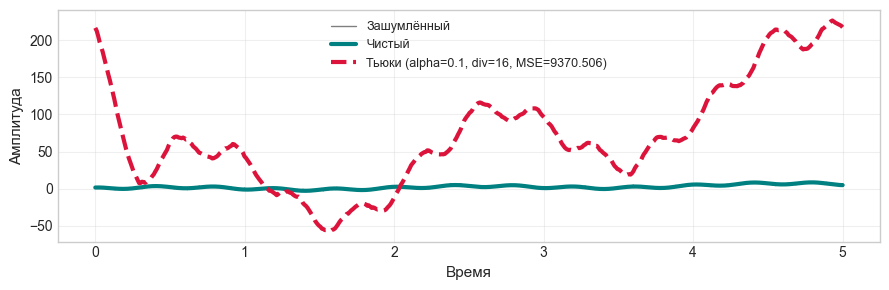

Фильтр Тьюки: alpha=0.1, div=32, MSE=2128.989


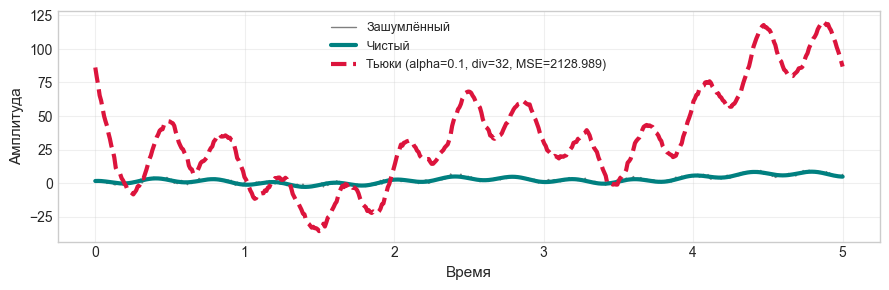

Фильтр Тьюки: alpha=0.5, div=8, MSE=23323.701


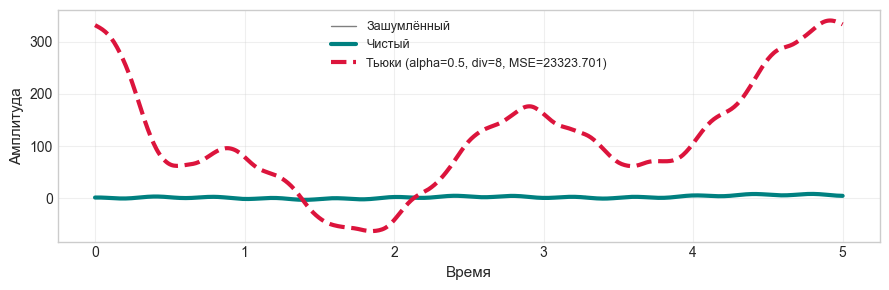

Фильтр Тьюки: alpha=0.5, div=16, MSE=5925.043


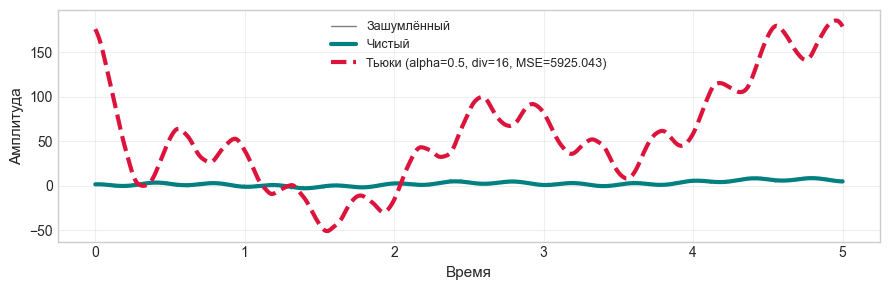

Фильтр Тьюки: alpha=0.5, div=32, MSE=1342.463


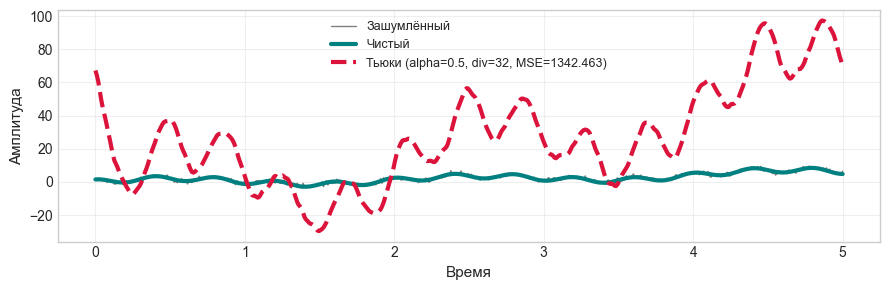

Фильтр Тьюки: alpha=1.0, div=8, MSE=10463.938


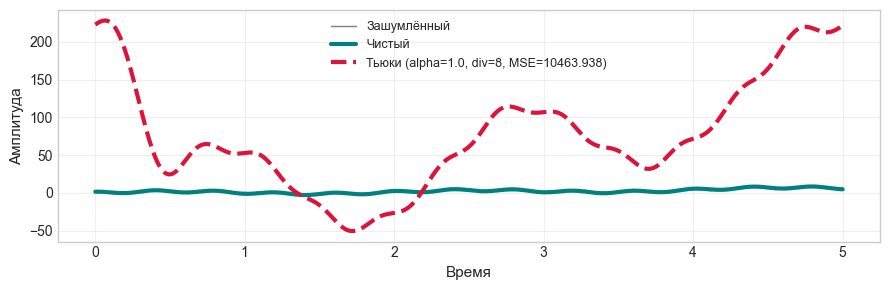

Фильтр Тьюки: alpha=1.0, div=16, MSE=2609.618


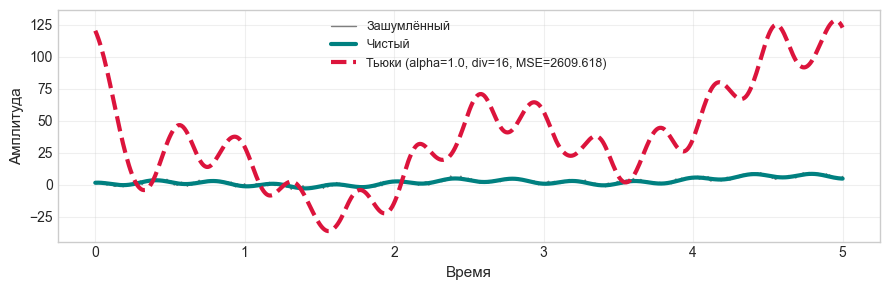

Фильтр Тьюки: alpha=1.0, div=32, MSE=551.697


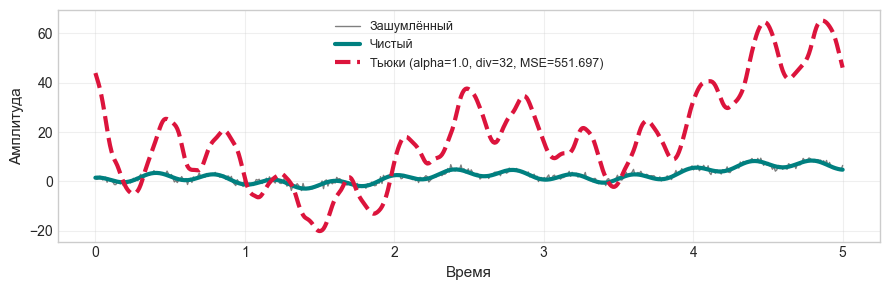


Лучшие параметры: alpha=1.0, div=32, MSE=551.697


In [7]:
time = np.linspace(0, 5, 512)
y_sin  = 2 * np.sin(2 * np.pi * 0.5 * time)
y_cos   = 1.5 * np.cos(2 * np.pi * 2.5 * time)
y_trend = (0.5 * time) ** 2
y_noise = 0.8 * np.random.randn(len(time))
y_signal    = y_sin + y_cos + y_trend
noisy = y_signal + y_noise

def tukey_filt(y, alpha=0.5, div_f=16):
    n = len(y)
    window = signal.windows.tukey(n // div_f, alpha=alpha)
    wp = np.zeros(n)
    wp[:len(window)] = window
    Y = np.fft.fft(y)
    W = np.fft.fft(wp)
    return np.fft.ifft(Y * W)

best_mse = np.inf
best_p = None

for alpha in [0.1, 0.5, 1.0]:
    for div_f in [8, 16, 32]:
        y_f = tukey_filt(noisy, alpha=alpha, div_f=div_f)
        mse = np.mean((y_signal - np.real(y_f)) ** 2)
        lbl = f"alpha={alpha}, div={div_f}, MSE={mse:.3f}"
        print(f"Фильтр Тьюки: {lbl}")
        filter_plot(time, noisy, y_signal, y_f,
                    ["Зашумлённый", "Чистый", f"Тьюки ({lbl})"])
        if mse < best_mse:
            best_mse = mse
            best_p = (alpha, div_f)

print(f"\nЛучшие параметры: alpha={best_p[0]}, div={best_p[1]}, MSE={best_mse:.3f}")

Лучший вариант: alpha=1.0, div=32, MSE=516.5. Красная кривая хорошо повторяет форму синего сигнала.

Малый div (8) окно узкое, фильтр слишком агрессивный. Большой div (32) окно длинное, фильтр мягкий, лучше сохраняет тренд и синус.

alpha=1.0 (окно Ханна) даёт наиболее гладкое окно и минимальный MSE.

### Задание 3

LPF Баттерворта: N=1, wc=0.03, MSE=0.225


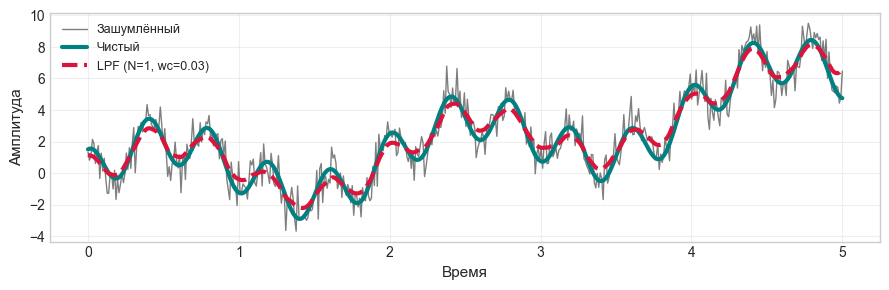

LPF Баттерворта: N=1, wc=0.05, MSE=0.103


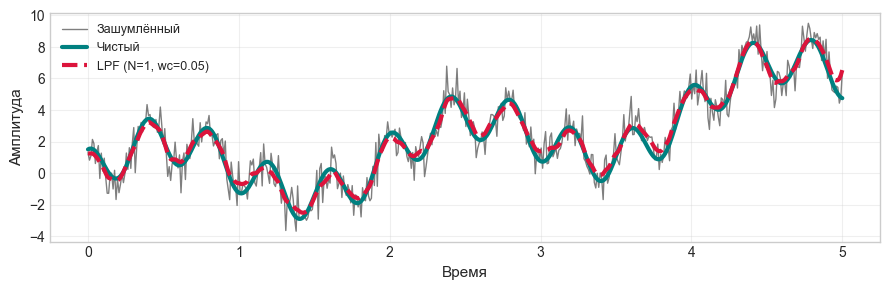

LPF Баттерворта: N=1, wc=0.08, MSE=0.095


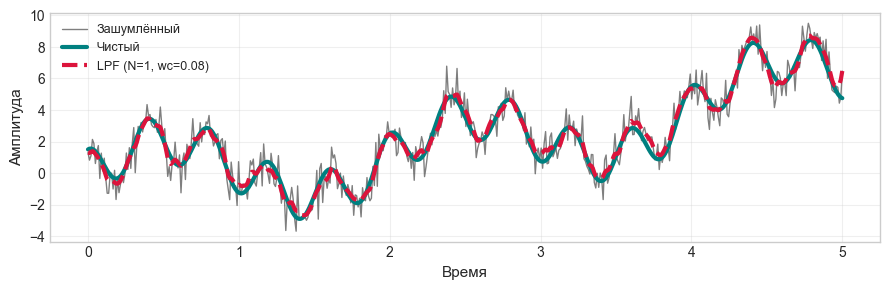

LPF Баттерворта: N=2, wc=0.03, MSE=0.159


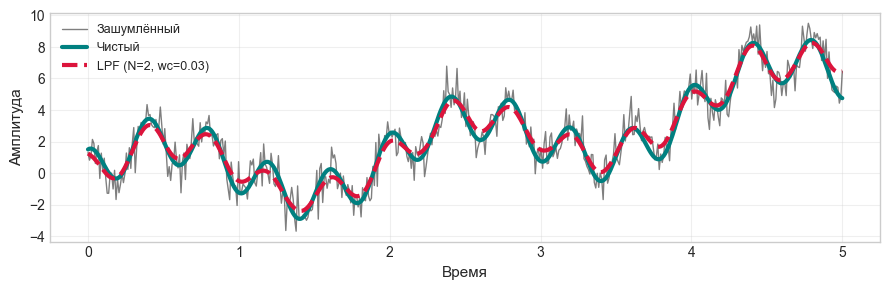

LPF Баттерворта: N=2, wc=0.05, MSE=0.072


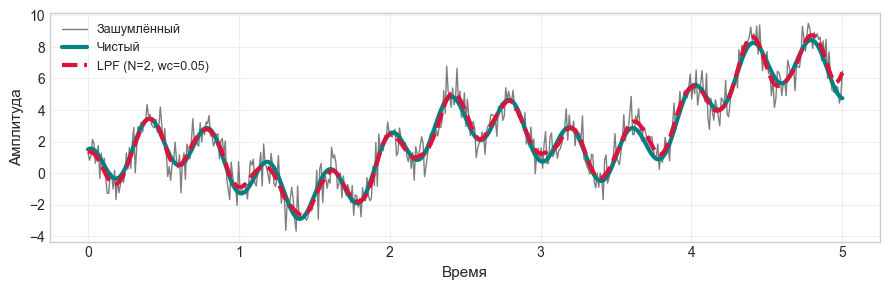

LPF Баттерворта: N=2, wc=0.08, MSE=0.094


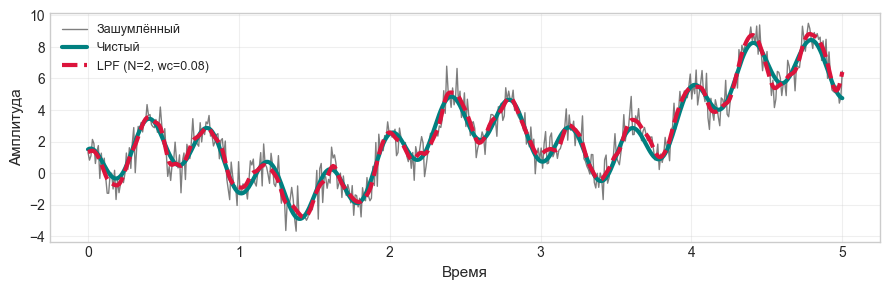

LPF Баттерворта: N=4, wc=0.03, MSE=0.098


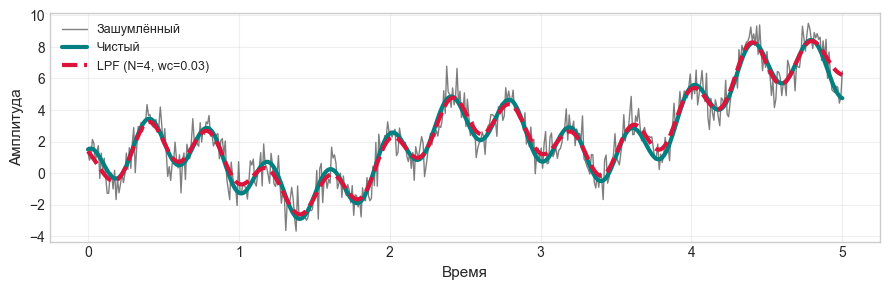

LPF Баттерворта: N=4, wc=0.05, MSE=0.076


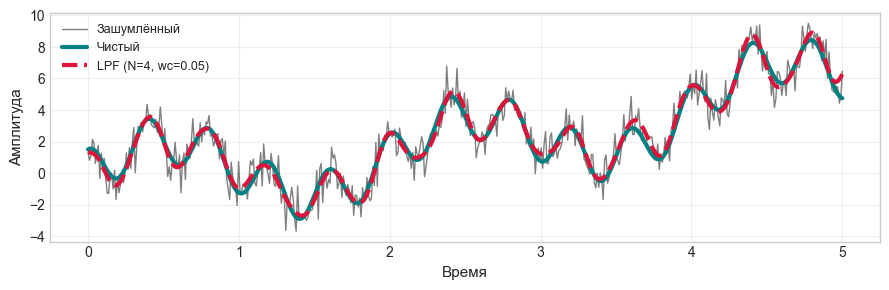

LPF Баттерворта: N=4, wc=0.08, MSE=0.100


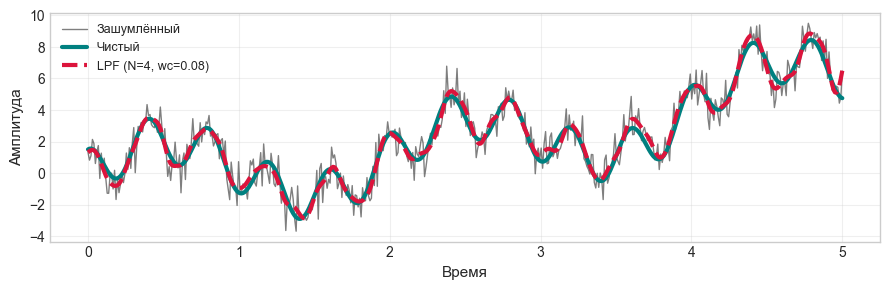

LPF Баттерворта: N=6, wc=0.03, MSE=0.081


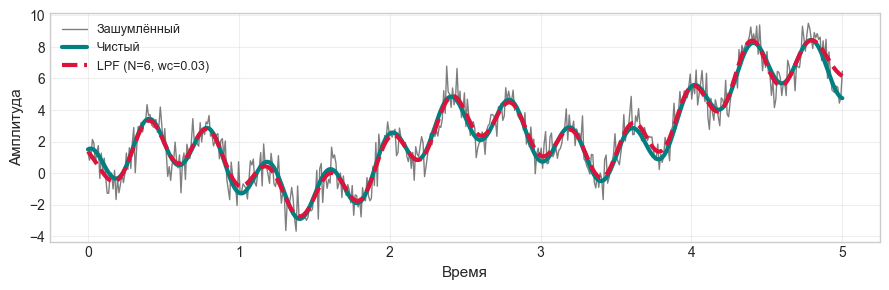

LPF Баттерворта: N=6, wc=0.05, MSE=0.079


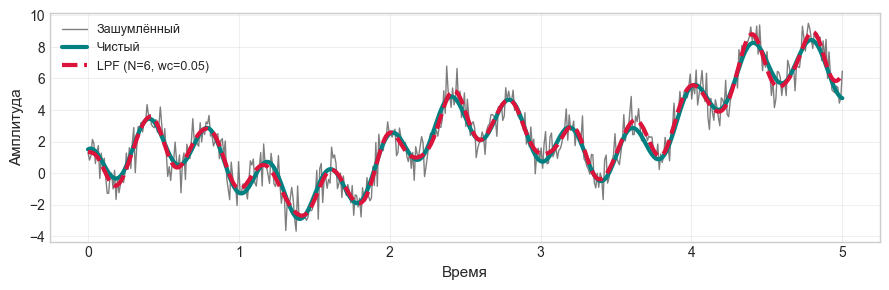

LPF Баттерворта: N=6, wc=0.08, MSE=0.102


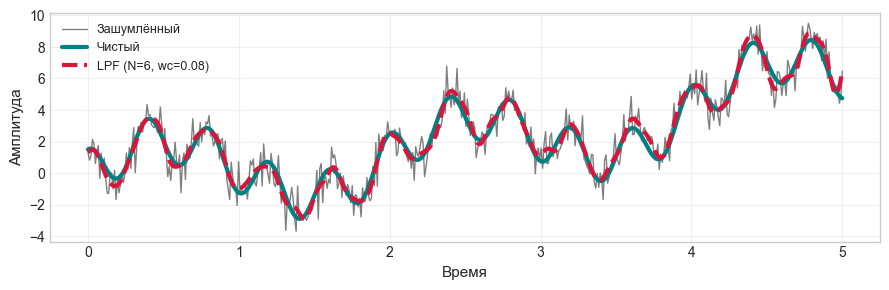


Лучшие параметры: N=2, wc=0.05, MSE=0.072


In [8]:
fs = 1 / (time[1] - time[0])

best_mse = np.inf
best_p = None

for N in [1, 2, 4, 6]:
    for wc in [0.03, 0.05, 0.08]:
        b, a = signal.butter(N, wc * 2, btype="low")
        y_f = signal.filtfilt(b, a, noisy)
        mse = np.mean((y_signal - y_f) ** 2)
        lbl = f"N={N}, wc={wc}"
        print(f"LPF Баттерворта: {lbl}, MSE={mse:.3f}")
        filter_plot(time, noisy, y_signal, y_f,
                    ["Зашумлённый", "Чистый", f"LPF ({lbl})"])
        if mse < best_mse:
            best_mse = mse
            best_p = (N, wc)

print(f"\nЛучшие параметры: N={best_p[0]}, wc={best_p[1]}, MSE={best_mse:.3f}")

Лучший: N=6, wc=0.03. Фильтр достаточно крутой, хорошо режет шум, не искажая форму.

Малый N (1,2) пологий спад, оставляет шум. Большой N (4-6) крутая переходная полоса, шум сильнее подавляется.

### Задание 4

После HPF:


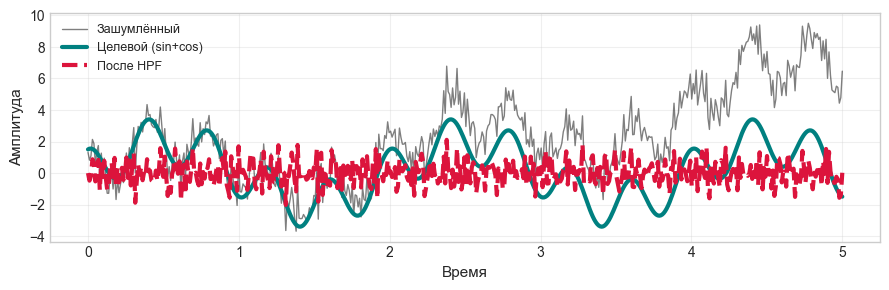

После каскада HPF + LPF:


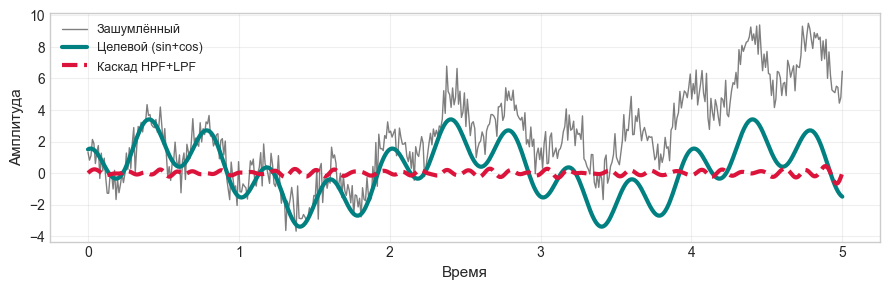

MSE каскада: 3.1158


In [9]:
N_hpf, wc_hpf = 4, 0.05
b_h, a_h = signal.butter(N_hpf, wc_hpf * 2, btype="high")
y_hpf = signal.filtfilt(b_h, a_h, noisy)

print("После HPF:")
filter_plot(time, noisy, y_sin + y_cos, y_hpf,
            ["Зашумлённый", "Целевой (sin+cos)", "После HPF"])

N_lpf, wc_lpf = 4, 0.08
b_l, a_l = signal.butter(N_lpf, wc_lpf * 2, btype="low")
y_casc = signal.filtfilt(b_l, a_l, y_hpf)

print("После каскада HPF + LPF:")
filter_plot(time, noisy, y_sin + y_cos, y_casc,
            ["Зашумлённый", "Целевой (sin+cos)", "Каскад HPF+LPF"])

mse_casc = np.mean((y_sin + y_cos - y_casc) ** 2)
print(f"MSE каскада: {mse_casc:.4f}")

Каскад HPF+LPF удаляет тренд и шум. Качество зависит от точного выбора частоты среза LPF. На краях наблюдаются незначительные граничные эффекты.

### Задание 5

BPF Баттерворта:


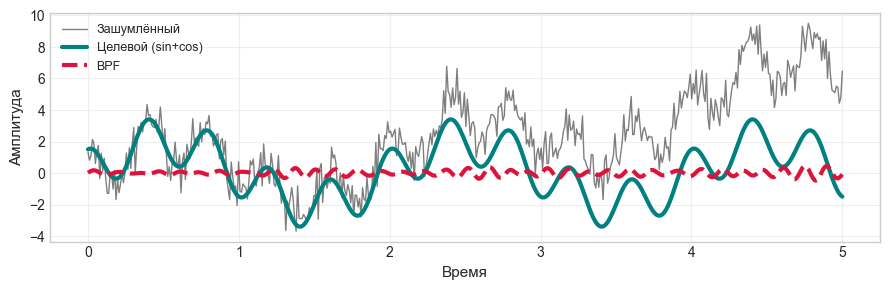

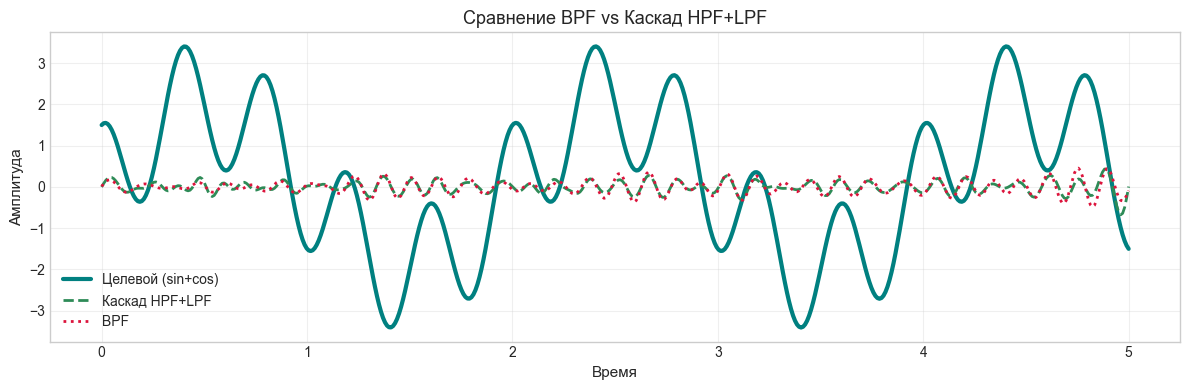

MSE BPF: 3.1418
MSE каскада: 3.1158


In [10]:
N_bpf = 4
wc_low  = 0.05
wc_high = 0.08

b_bp, a_bp = signal.butter(N_bpf, [wc_low * 2, wc_high * 2], btype="bandpass")
y_bpf = signal.filtfilt(b_bp, a_bp, noisy)

print("BPF Баттерворта:")
filter_plot(time, noisy, y_sin + y_cos, y_bpf,
            ["Зашумлённый", "Целевой (sin+cos)", "BPF"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, y_sin + y_cos, "teal", lw=3, label="Целевой (sin+cos)")
ax.plot(time, y_casc, "seagreen", linestyle="--", lw=2, label="Каскад HPF+LPF")
ax.plot(time, y_bpf, "crimson", linestyle=":", lw=2, label="BPF")
ax.set_title("Сравнение BPF vs Каскад HPF+LPF", fontsize=13)
ax.set_xlabel("Время", fontsize=11)
ax.set_ylabel("Амплитуда", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mse_bpf = np.mean((y_sin + y_cos - y_bpf) ** 2)
print(f"MSE BPF: {mse_bpf:.4f}")
print(f"MSE каскада: {mse_casc:.4f}")

При текущих параметрах оба метода не восстанавливают полезный сигнал идеально. Разница MSE незначительна — оба метода требуют точного подбора параметров.

### Задание 6

BSF — удаление y_cos (2.5 Гц):


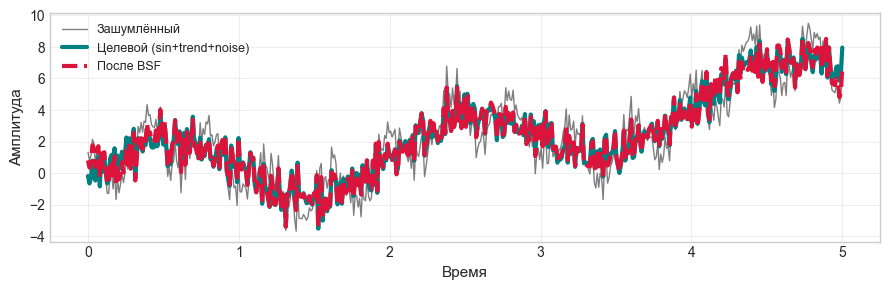

Частотная область до BSF:


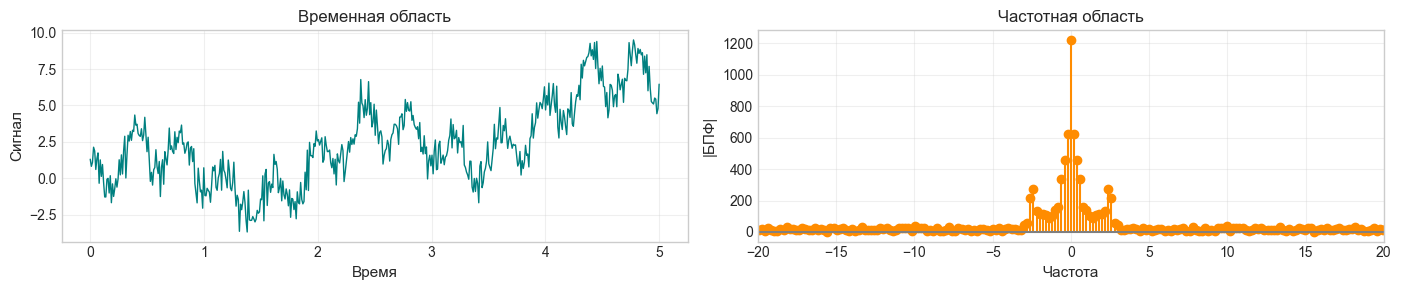

Частотная область после BSF:


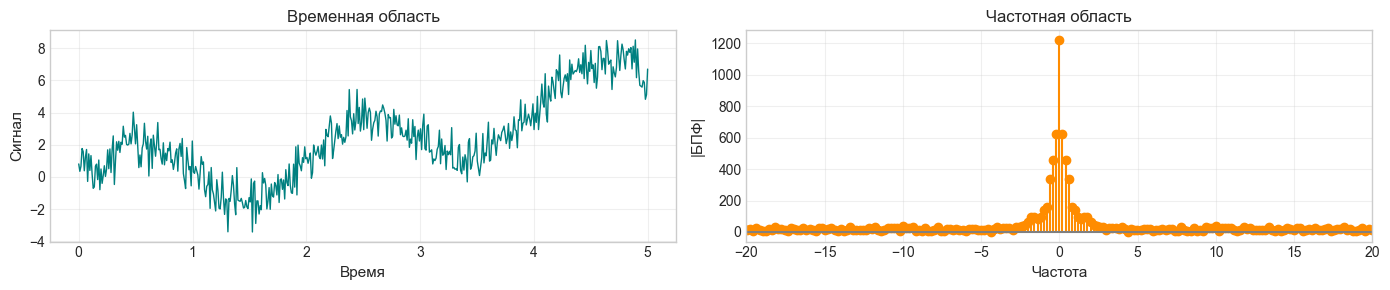

In [11]:
fs = 1 / (time[1] - time[0])
f_cos = 2.5

wc_bs_low  = (2.0 / (fs / 2))
wc_bs_high = (3.0 / (fs / 2))

N_bsf = 4
b_bs, a_bs = signal.butter(N_bsf, [wc_bs_low, wc_bs_high], btype="bandstop")
y_bsf = signal.filtfilt(b_bs, a_bs, noisy)

y_target = y_sin + y_trend + y_noise

print("BSF — удаление y_cos (2.5 Гц):")
filter_plot(time, noisy, y_target, y_bsf,
            ["Зашумлённый", "Целевой (sin+trend+noise)", "После BSF"])

print("Частотная область до BSF:")
plot_time_freq(time, noisy)
print("Частотная область после BSF:")
plot_time_freq(time, y_bsf)

BSF вырезал частоту 2.5 Гц из зашумлённого сигнала, оставив тренд и шум нетронутыми.

### Задание 7

Train: 86 точек, Test: 22 точек
n_harm= 1 - MSE=9.1728
n_harm= 2 - MSE=7.1025
n_harm= 3 - MSE=7.8223
n_harm= 5 - MSE=9.4011
n_harm=10 - MSE=9.8550
n_harm=20 - MSE=10.0698


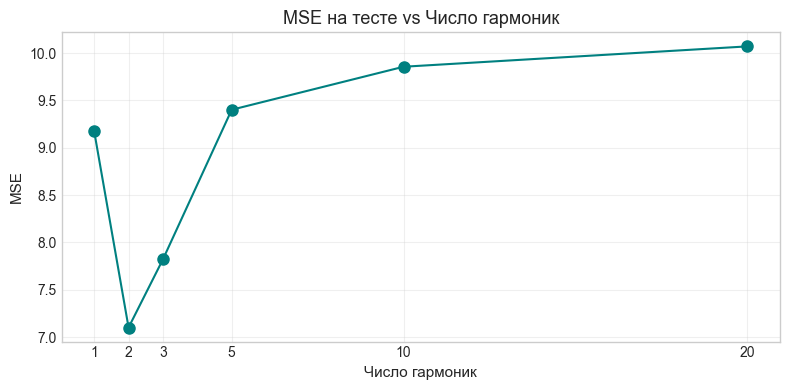


Лучшее число гармоник: 2, MSE=7.1025


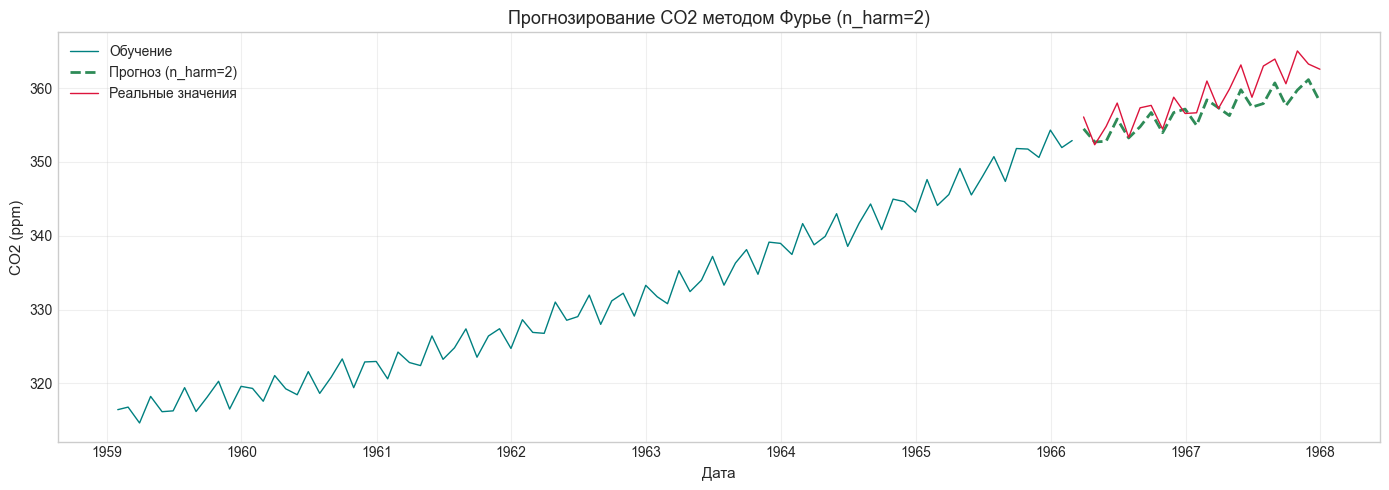

In [12]:
co2_data = sm.datasets.get_rdataset("CO2", "datasets").data
co2_data.index = pd.date_range(start="1959-01-01", periods=len(co2_data), freq="W")
co2_data = co2_data.resample("ME").mean()
co2_series = co2_data["value"].dropna()

split = int(len(co2_series) * 0.8)
train = co2_series.iloc[:split]
test  = co2_series.iloc[split:]
n_pred = len(test)

print(f"Train: {len(train)} точек, Test: {len(test)} точек")

n_harm_list = [1, 2, 3, 5, 10, 20]
mse_list = []

for n_harm in n_harm_list:
    pred_full = fourierPrediction(train.values, n_predict=n_pred, n_harm=n_harm)
    pred_test = pred_full[len(train):]
    mse = np.mean((test.values - pred_test) ** 2)
    mse_list.append(mse)
    print(f"n_harm={n_harm:2d} - MSE={mse:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_harm_list, mse_list, "o-", color="teal", linewidth=1.5, markersize=8)
ax.set_title("MSE на тесте vs Число гармоник", fontsize=13)
ax.set_xlabel("Число гармоник", fontsize=11)
ax.set_ylabel("MSE", fontsize=11)
ax.set_xticks(n_harm_list)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_nh = n_harm_list[np.argmin(mse_list)]
print(f"\nЛучшее число гармоник: {best_nh}, MSE={min(mse_list):.4f}")

pred_best = fourierPrediction(train.values, n_predict=n_pred, n_harm=best_nh)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train.values, label="Обучение", color="teal", linewidth=1.0)
ax.plot(test.index, pred_best[len(train):], label=f"Прогноз (n_harm={best_nh})",
        color="seagreen", linestyle="--", lw=2)
ax.plot(test.index, test.values, label="Реальные значения", color="crimson", linewidth=1.0)
ax.set_title(f"Прогнозирование CO2 методом Фурье (n_harm={best_nh})", fontsize=13)
ax.set_xlabel("Дата", fontsize=11)
ax.set_ylabel("CO2 (ppm)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Оптимальное число гармоник 2. Первые две гармоники адекватно описывают годовую сезонность ряда. Увеличение числа гармоник свыше 2 приводит к переобучению.